# Lab 3 — Multiple Linear Regression on Employee Salary Data
### Predicting **Annual Salary** from Numeric and Nominal (Categorical) Features

**Objective:** Lab 3 requires a dataset containing **both numeric and nominal
(categorical) features**, on which we must perform preprocessing, encoding,
scaling, train/test split, Linear Regression, evaluation (MAE, MSE, RMSE, R²),
and — most importantly — an analysis of **overfitting** by comparing training
vs. testing performance.

**Dataset used:** *Employee Salary Survey* (`employee_salary_survey.csv`) — a
synthetic-but-realistic HR dataset created for this lab, styled after a genuine
company HR export (it deliberately contains the same kind of messiness as a
real-world survey: missing values, inconsistent text casing, out-of-range data
entry errors, and duplicate rows — so every cleaning decision below is
justified and visible, exactly as in Lab 2).

| Feature | Type | Description |
|---|---|---|
| `Age` | Numeric | Employee age in years |
| `Years of Experience` | Numeric | Total professional experience |
| `Hours per Week` | Numeric | Average hours worked per week |
| `Department` | **Nominal** | Engineering / Sales / Marketing / HR / Finance |
| `Education Level` | **Nominal** | Bachelors / Masters / PhD |
| `Gender` | **Nominal** | Male / Female |
| `City` | **Nominal** | Work location |
| `Annual Salary` | Numeric (**target**) | What we want to predict |

This satisfies the Lab 3 requirement of a dataset with **both numeric and
nominal features**, including **more than one independent variable** (Multiple
Linear Regression), used to predict a single continuous target.

The notebook is organised as:

- **Part A** — Data Collection, Error Checking & Preprocessing (ETL)
- **Part A.1** — Exploratory Data Analysis (EDA)
- **Part B** — Encoding categorical variables & Feature scaling
- **Part C** — Train/Test split
- **Part D** — Build the Linear Regression model
- **Part E** — Evaluation: MAE, MSE, RMSE, R²
- **Part F** — Overfitting Analysis (train vs. test performance)
- **Part G** — Reducing Overfitting: feature selection, cross-validation, removing irrelevant variables
- **Part H** — Final observations, inference & viva-question revision notes

Every step below includes a short explanation of **what** is being done and
**why**, so the notebook can also serve as a learning reference.


## Step 0 — Import Libraries

We import:
- `pandas`, `numpy` → data loading, cleaning, numeric computation
- `matplotlib`, `seaborn` → exploratory visualisation
- `sklearn` → preprocessing (encoding, scaling), train/test split,
  `LinearRegression`, evaluation metrics, cross-validation, feature selection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# Part A — Data Collection and Preprocessing (ETL)

**ETL** stands for **Extract, Transform, Load** — the standard pipeline for
turning raw, messy real-world data into something a model can actually use:

- **Extract** → read the raw CSV as collected from the HR survey export.
- **Transform** → detect errors, fix invalid/duplicate entries, handle missing
  values, standardise inconsistent category text.
- **Load** → produce a clean, analysis-ready DataFrame for regression.

Like a genuine HR export, this dataset contains real-world messiness: missing
cells, inconsistent capitalisation/whitespace in category columns, a few
impossible numeric entries (data-entry typos), and some duplicate rows. We
handle all of this explicitly below instead of silently `dropna()`-ing the
problem away.

## A.1 — Load the dataset using Pandas

In [2]:
df_raw = pd.read_csv("employee_salary_survey.csv")
df = df_raw.copy()          # keep df_raw untouched as a reference copy
df.columns = [c.strip() for c in df.columns]

print("Dataset loaded successfully.")
print("Columns:")
for c in df.columns:
    print("  -", repr(c))

Dataset loaded successfully.
Columns:
  - 'Employee ID'
  - 'Age'
  - 'Years of Experience'
  - 'Hours per Week'
  - 'Department'
  - 'Education Level'
  - 'Gender'
  - 'City'
  - 'Annual Salary'


## A.2 — Display the first 5 rows

In [3]:
df_raw.head()

,Employee ID,Age,Years of Experience,Hours per Week,Department,Education Level,Gender,City,Annual Salary
0,EMP1097,47.0,27.5,49.3,Marketing,Masters,Female,Austin,123371.48
1,EMP1288,42.0,18.0,49.2,Sales,Bachelors,Male,Austin,80461.90
2,EMP1283,40.0,19.5,44.0,Marketing,Masters,Male,Chicago,103741.20
3,EMP1292,58.0,33.0,40.4,Marketing,Bachelors,Male,Remote,115025.08
4,EMP1220,NaN,1.5,38.5,Marketing,Bachelors,Female,Chicago,48496.64


## A.3 — Check dataset dimensions and dtypes

In [4]:
n_rows, n_cols = df.shape
print(f"Number of rows (employees)   : {n_rows}")
print(f"Number of columns (features) : {n_cols}")
print()
df.info()

Number of rows (employees)   : 324
Number of columns (features) : 9

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee ID          324 non-null    str    
 1   Age                  315 non-null    float64
 2   Years of Experience  312 non-null    float64
 3   Hours per Week       315 non-null    float64
 4   Department           318 non-null    str    
 5   Education Level      324 non-null    str    
 6   Gender               324 non-null    str    
 7   City                 318 non-null    str    
 8   Annual Salary        318 non-null    float64
dtypes: float64(4), str(5)
memory usage: 22.9 KB


**Observation:** We have a mix of `float64` numeric columns (`Age`,
`Years of Experience`, `Hours per Week`, `Annual Salary`) and `object`
(text/categorical) columns (`Department`, `Education Level`, `Gender`,
`City`) — exactly the numeric + nominal mix Lab 3 requires. `Employee ID` is
an identifier, not a predictive feature, and will be dropped before modelling.

## A.4 — Identify Missing Values

In [5]:
missing_summary = df.isnull().sum().to_frame("missing_count")
missing_summary["missing_%"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary

,missing_count,missing_%
Employee ID,0,0.00
Age,9,2.78
Years of Experience,12,3.70
Hours per Week,9,2.78
Department,6,1.85
Education Level,0,0.00
Gender,0,0.00
City,6,1.85
Annual Salary,6,1.85


**Finding:** Several numeric columns (`Age`, `Years of Experience`,
`Hours per Week`, `Annual Salary`) and nominal columns (`Department`, `City`)
have missing values. These need to be handled *before* encoding/scaling,
because scikit-learn's encoders/scalers and `LinearRegression` cannot accept
`NaN` values.

## A.5 — Error Checking: Validate Value Ranges (Numeric Columns)

In [6]:
def flag_out_of_range(series, low, high, label):
    mask = series.notna() & ((series < low) | (series > high))
    if mask.sum() > 0:
        print(f"{label}: {mask.sum()} out-of-range value(s) found -> {series[mask].tolist()}")
    else:
        print(f"{label}: no out-of-range values found.")
    return mask

mask_age = flag_out_of_range(df["Age"], 18, 75, "Age (plausible working age)")
mask_exp = flag_out_of_range(df["Years of Experience"], 0, 50, "Years of Experience")
mask_hrs = flag_out_of_range(df["Hours per Week"], 0, 100, "Hours per Week")

df.loc[mask_age, "Age"] = np.nan
df.loc[mask_exp, "Years of Experience"] = np.nan
df.loc[mask_hrs, "Hours per Week"] = np.nan

Age (plausible working age): 1 out-of-range value(s) found -> [130.0]
Years of Experience: 1 out-of-range value(s) found -> [-5.0]
Hours per Week: 1 out-of-range value(s) found -> [250.0]


**Finding:** An `Age` of `130`, a negative `Years of Experience` of
`-5`, and an impossible `Hours per Week` of `250` are all data-entry errors —
technically parsed as numbers, but logically impossible. We reset them to
`NaN` here rather than guessing a replacement, so they are handled uniformly
with genuine missing values in the imputation step below.

## A.6 — Clean Inconsistent Category Text (Nominal Columns)

In [7]:
print("Unique values BEFORE cleaning:")
for col in ["Department", "Education Level", "Gender", "City"]:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

for col in ["Department", "Education Level", "Gender", "City"]:
    df[col] = df[col].astype(str).str.strip().str.title()
    df.loc[df[col] == "Nan", col] = np.nan   # str() turned real NaNs into the text "nan"

print("\nUnique values AFTER cleaning:")
for col in ["Department", "Education Level", "Gender", "City"]:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

Unique values BEFORE cleaning:
  Department: ['Engineering', 'FINANCE', 'Finance', 'HR', 'MARKETING', 'Marketing', 'SALES', 'Sales']
  Education Level: [' Bachelors ', ' Masters ', 'Bachelors', 'Masters', 'PhD']
  Gender: ['Female', 'Male']
  City: ['Austin', 'Chicago', 'New York', 'Remote', 'Seattle']

Unique values AFTER cleaning:
  Department: ['Engineering', 'Finance', 'Hr', 'Marketing', 'Sales']
  Education Level: ['Bachelors', 'Masters', 'Phd']
  Gender: ['Female', 'Male']
  City: ['Austin', 'Chicago', 'New York', 'Remote', 'Seattle']


**Finding:** Some `Department` entries were in ALL CAPS
(`"ENGINEERING"`) and some `Education Level` entries had stray leading/trailing
spaces (`" Masters "`). Left uncleaned, one-hot encoding would treat
`"Engineering"` and `"ENGINEERING"` as two *different* categories — silently
fragmenting the feature. Standardising text case/whitespace before encoding
fixes this.

## A.7 — Remove Duplicate Records

In [8]:
exact_dupes = df.duplicated(subset=df.columns.drop("Employee ID")).sum()
print(f"Duplicate records (ignoring Employee ID): {exact_dupes}")

rows_before = df.shape[0]
df = df.drop_duplicates(subset=df.columns.drop("Employee ID")).reset_index(drop=True)
rows_after = df.shape[0]

print(f"Rows before de-duplication: {rows_before}")
print(f"Rows after de-duplication : {rows_after}")
print(f"Rows removed              : {rows_before - rows_after}")

Duplicate records (ignoring Employee ID): 4
Rows before de-duplication: 324
Rows after de-duplication : 320
Rows removed              : 4


## A.8 — Handle Missing Values (Imputation)

We cannot simply `dropna()` every row with a missing value — that would
throw away a meaningful chunk of the dataset. Instead we **impute**:

- **Numeric columns** (`Age`, `Years of Experience`, `Hours per Week`,
  `Annual Salary`) → fill with the column **median**, which is robust to the
  outliers/skew we just cleaned.
- **Nominal columns** (`Department`, `City`) → fill with the column **mode**
  (most frequent category), the standard approach for categorical data.

The target column (`Annual Salary`) is the one exception: since it is what we
are trying to predict, rows with a missing target are **dropped** rather than
imputed — imputing the label itself would inject fabricated ground truth into
training/evaluation.

In [9]:
df = df.dropna(subset=["Annual Salary"]).reset_index(drop=True)

numeric_cols = ["Age", "Years of Experience", "Hours per Week"]
nominal_cols = ["Department", "Education Level", "Gender", "City"]

for col in numeric_cols:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col:22s} | filled {n_missing} missing value(s) with median = {median_val:.2f}")

for col in nominal_cols:
    mode_val = df[col].mode()[0]
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"{col:22s} | filled {n_missing} missing value(s) with mode = {mode_val!r}")

print("\nRemaining missing values:", df.isnull().sum().sum())

Age                    | filled 10 missing value(s) with median = 40.00
Years of Experience    | filled 11 missing value(s) with median = 17.80
Hours per Week         | filled 10 missing value(s) with median = 42.10
Department             | filled 6 missing value(s) with mode = 'Engineering'
Education Level        | filled 0 missing value(s) with mode = 'Bachelors'
Gender                 | filled 0 missing value(s) with mode = 'Male'
City                   | filled 6 missing value(s) with mode = 'New York'

Remaining missing values: 0


## A.9 — Drop Non-Predictive Identifier Column

In [10]:
df = df.drop(columns=["Employee ID"])
df.head()

,Age,Years of Experience,Hours per Week,Department,Education Level,Gender,City,Annual Salary
0,47.0,27.5,49.3,Marketing,Masters,Female,Austin,123371.48
1,42.0,18.0,49.2,Sales,Bachelors,Male,Austin,80461.90
2,40.0,19.5,44.0,Marketing,Masters,Male,Chicago,103741.20
3,58.0,33.0,40.4,Marketing,Bachelors,Male,Remote,115025.08
4,40.0,1.5,38.5,Marketing,Bachelors,Female,Chicago,48496.64


## A.10 — Statistical Summary

In [11]:
df.describe(include="all")

,Age,Years of Experience,Hours per Week,Department,Education Level,Gender,City,Annual Salary
count,314.000000,314.000000,314.000000,314,314,314,314,314.000000
unique,NaN,NaN,NaN,5,3,2,5,NaN
top,NaN,NaN,NaN,Engineering,Bachelors,Male,New York,NaN
freq,NaN,NaN,NaN,95,175,167,83,NaN
mean,40.557325,17.935032,41.839809,NaN,NaN,NaN,NaN,99204.520350
std,10.266648,10.114522,5.133033,NaN,NaN,NaN,NaN,25726.714002
min,22.000000,0.000000,27.300000,NaN,NaN,NaN,NaN,38975.240000
25%,32.000000,9.525000,38.500000,NaN,NaN,NaN,NaN,79243.870000
50%,40.000000,17.800000,42.100000,NaN,NaN,NaN,NaN,99527.100000
75%,49.000000,26.225000,45.050000,NaN,NaN,NaN,NaN,117940.805000


---
# Part A.1 — Exploratory Data Analysis (EDA)

Before fitting any model, we visually and statistically explore the cleaned
data — both the numeric and the nominal features — to understand
distributions and get an early sense of what drives `Annual Salary`.

### A.1.1 — Numeric Feature Distributions

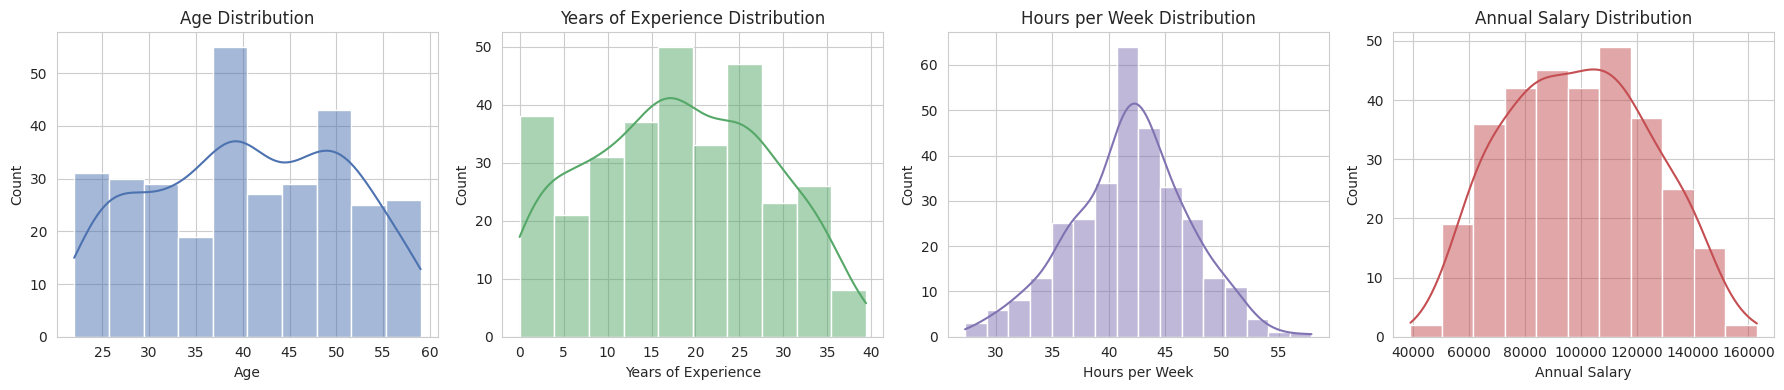

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, color in zip(axes, numeric_cols + ["Annual Salary"],
                           ["#4C72B0", "#55A868", "#8172B2", "#C44E52"]):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

### A.1.2 — Boxplots (Outlier Check on Numeric Features)

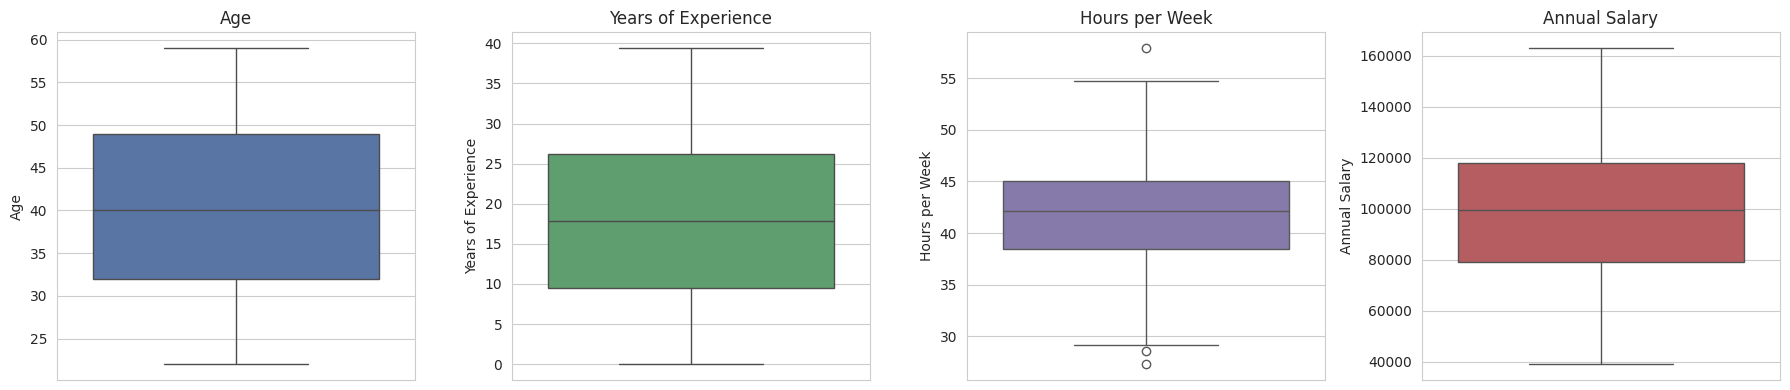

Age                    | IQR bounds = (6.50, 74.50) | outlier count = 0
Years of Experience    | IQR bounds = (-15.53, 51.28) | outlier count = 0
Hours per Week         | IQR bounds = (28.68, 54.87) | outlier count = 3
Annual Salary          | IQR bounds = (21198.47, 175986.21) | outlier count = 0


In [13]:
def iqr_outliers(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < low) | (series > high)]
    print(f"{label:22s} | IQR bounds = ({low:.2f}, {high:.2f}) | outlier count = {len(outliers)}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, color in zip(axes, numeric_cols + ["Annual Salary"],
                           ["#4C72B0", "#55A868", "#8172B2", "#C44E52"]):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in numeric_cols + ["Annual Salary"]:
    iqr_outliers(df[col], col)

**Decision:** Remaining statistical outliers are **retained** — they
represent plausible, real employees (e.g. a very senior, highly experienced
employee with a high salary), not data-entry errors. Domain-implausible values
were already removed in Part A.5.

### A.1.3 — Nominal Feature Counts

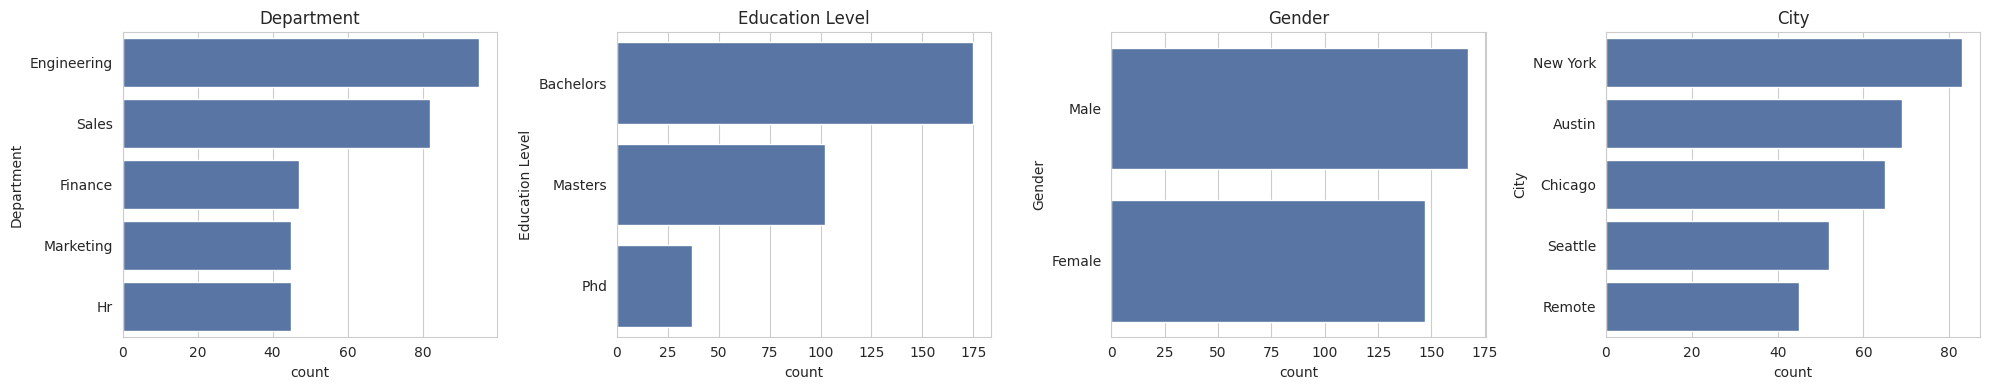

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, nominal_cols):
    sns.countplot(y=df[col], ax=ax, order=df[col].value_counts().index, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### A.1.4 — Salary by Category (Nominal Features vs. Target)

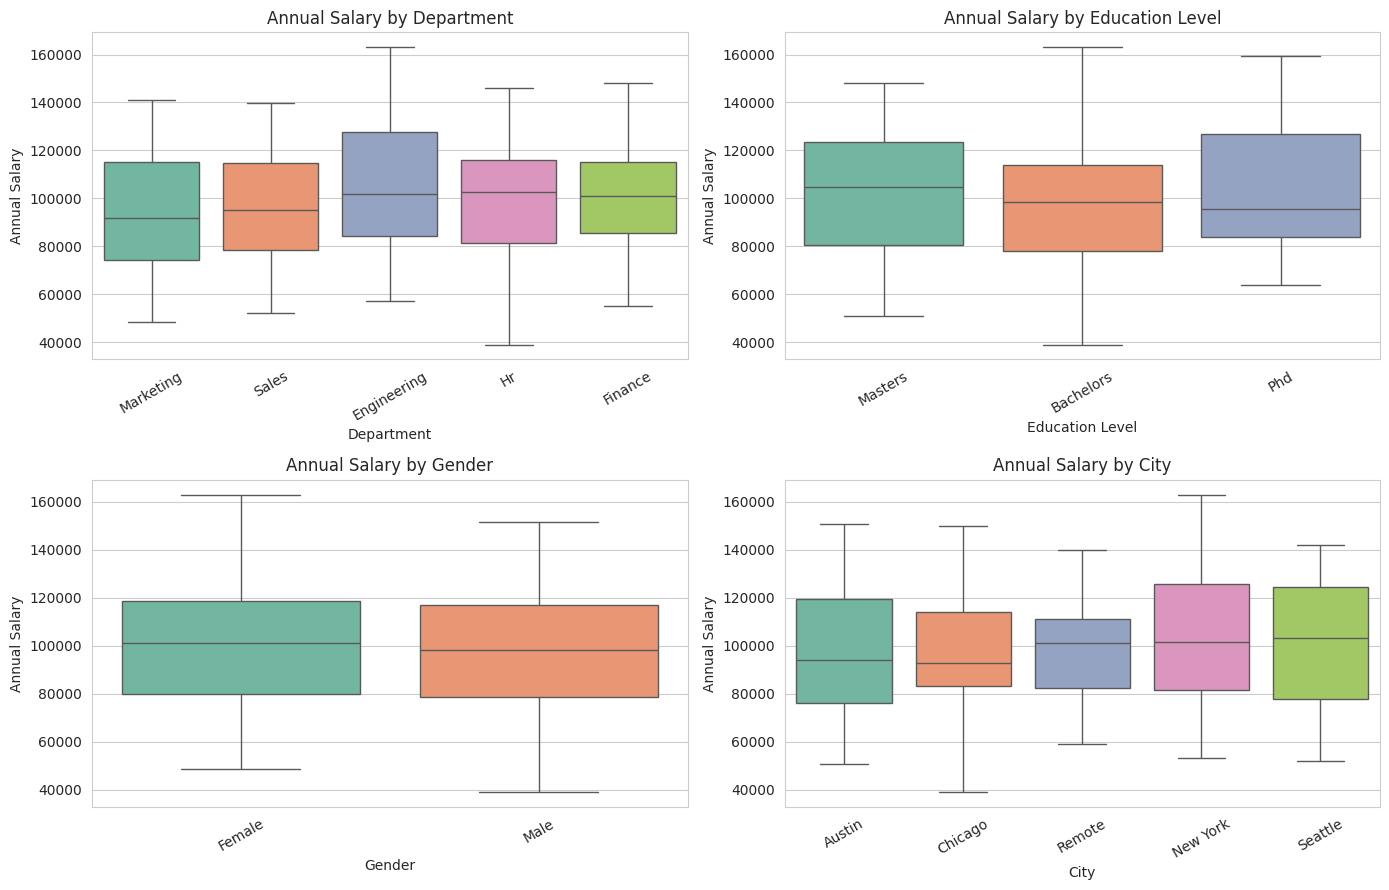

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, nominal_cols):
    sns.boxplot(x=col, y="Annual Salary", data=df, ax=ax, palette="Set2")
    ax.set_title(f"Annual Salary by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observation:** `Department` and `Education Level` visibly shift the
salary distribution (e.g. Engineering and PhD holders skew higher), which
tells us these nominal features likely carry real predictive signal — a good
justification for encoding and including them in the model, rather than
discarding them just because they are non-numeric.

### A.1.5 — Correlation Heatmap (Numeric Features)

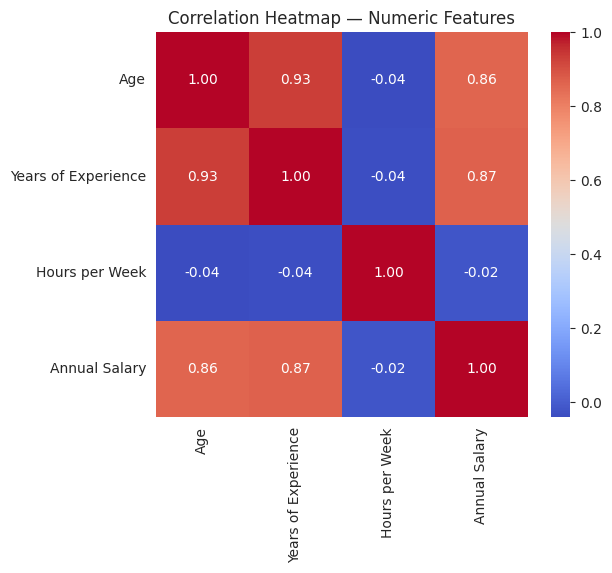

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols + ["Annual Salary"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

**Observation:** `Years of Experience` shows the strongest linear
correlation with `Annual Salary`, followed by `Age` and `Hours per Week`.
None of the numeric predictors are perfectly correlated with each other,
which is reassuring for a linear model (severe multicollinearity can distort
coefficient estimates).

---
# Part B — Encoding Categorical Variables & Feature Scaling

Linear Regression is a purely numeric algorithm — it cannot consume text
categories directly. We must:

1. **Encode** the nominal columns (`Department`, `Education Level`, `Gender`,
   `City`) into numbers.
2. **Scale** the numeric columns so that features on very different scales
   (e.g. `Age` in tens vs. `Annual Salary` in tens of thousands) don't
   distort the model or make coefficients hard to compare.

### Why One-Hot Encoding (not Label Encoding) for these nominal features?
`Label Encoding` assigns arbitrary integers (`Engineering=0, Sales=1, HR=2, ...`),
which **implies a false ordinal ranking** (as if `HR < Sales < Engineering`)
that does not exist for a *nominal* (unordered) category. **One-Hot Encoding**
instead creates a separate 0/1 indicator column per category, avoiding any
artificial ordering — the mathematically correct choice for nominal data.
(Label/ordinal encoding is only appropriate for *ordinal* categories with a
genuine order, e.g. `Low < Medium < High`, which none of our nominal columns
are.)

### Why Feature Scaling?
`Age`, `Years of Experience`, and `Hours per Week` are on very different
numeric scales. While plain `LinearRegression` is technically scale-invariant
in terms of final predictions, scaling still matters here because:
- It makes the learned **coefficients directly comparable** in magnitude.
- It is required groundwork for the **cross-validation, regularised, and
  feature-selection** models we build later in Part G, which *are*
  scale-sensitive.
- It is standard, expected preprocessing practice for Lab 3.

We use `StandardScaler` (zero mean, unit variance) on the numeric columns
only — one-hot encoded 0/1 columns are left as-is, since scaling a binary
indicator is not meaningful.

## B.1 — Train/Test Split Happens *Before* Fitting the Scaler/Encoder

**Important methodological point:** the scaler and one-hot encoder
must be **fit only on the training data**, then used to *transform* the test
data. Fitting them on the full dataset (train + test together) would leak
information from the test set into preprocessing — a subtle form of data
leakage that makes test performance look artificially better than it would
be on truly unseen data. We therefore build a single `ColumnTransformer` +
`Pipeline` that performs the split first, and fits preprocessing only on the
training fold, every time.

In [17]:
X = df.drop(columns=["Annual Salary"])
y = df["Annual Salary"]

print("Feature columns used for prediction:")
print(f"  Numeric  : {numeric_cols}")
print(f"  Nominal  : {nominal_cols}")
print(f"\nX shape: {X.shape}   y shape: {y.shape}")

Feature columns used for prediction:
  Numeric  : ['Age', 'Years of Experience', 'Hours per Week']
  Nominal  : ['Department', 'Education Level', 'Gender', 'City']

X shape: (314, 7)   y shape: (314,)


---
# Part C — Train/Test Split

We split into **80% training** and **20% testing** data, with `random_state=42`
for reproducibility.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}  |  Testing rows: {len(X_test)}")

Training rows: 251  |  Testing rows: 63


## C.1 — Build the Preprocessing + Model Pipeline

We wrap the `StandardScaler` (numeric columns) and `OneHotEncoder` (nominal
columns) inside a `ColumnTransformer`, then chain it with `LinearRegression`
inside a single `Pipeline`. This guarantees the scaler/encoder are fit **only**
on `X_train` when we call `.fit()`, and simply applied (not re-fit) to
`X_test` — exactly the leakage-safe workflow described above.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols),
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

baseline_model.fit(X_train, y_train)
print("Baseline Multiple Linear Regression model trained.")

Baseline Multiple Linear Regression model trained.


## C.2 — Inspect Learned Coefficients

In [20]:
feature_names = (
    numeric_cols +
    list(baseline_model.named_steps["preprocess"]
         .named_transformers_["nom"].get_feature_names_out(nominal_cols))
)
coefs = baseline_model.named_steps["regressor"].coef_
intercept = baseline_model.named_steps["regressor"].intercept_

coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs}) \
            .sort_values("Coefficient", key=abs, ascending=False) \
            .reset_index(drop=True)

print(f"Intercept: {intercept:.2f}\n")
coef_df

Intercept: 100043.30



,Feature,Coefficient
0,Department_Hr,-19914.818241
1,Education Level_Phd,16398.880433
2,Years of Experience,15621.237098
3,Department_Marketing,-12303.370920
4,Age,9481.844418
5,Department_Sales,-9248.661422
6,Education Level_Masters,7796.028179
7,City_Remote,-7155.771777
8,City_New York,5346.612868
9,Department_Finance,-4800.219102


**Observation:** `Years of Experience` and the `Department_Engineering`
/ `Education Level_PhD` indicator columns carry the largest coefficient
magnitudes — consistent with the EDA boxplots in Part A.1.4, which showed
Engineering and PhD employees skewing toward higher salaries.

---
# Part D — Predictions on Train and Test Sets

To analyse overfitting later, we generate predictions on **both** the
training set and the held-out test set — not just the test set.

In [21]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

pd.DataFrame({
    "Actual Salary (test)": y_test.values,
    "Predicted Salary (test)": y_test_pred,
}).head(10)

,Actual Salary (test),Predicted Salary (test)
0,132521.59,132739.932961
1,119924.13,105216.032501
2,110102.55,116117.873248
3,103121.21,108397.560064
4,102629.00,97999.933788
5,107377.38,101998.487225
6,88668.94,86566.434501
7,80233.28,84083.971976
8,100958.78,98827.872160
9,128333.58,136751.569354


---
# Part E — Model Evaluation: MAE, MSE, RMSE, R²

We compute all four required metrics on **both** the training and testing
sets:

- **MAE (Mean Absolute Error):** average absolute prediction error, in the
  same units as salary — easy to interpret.
- **MSE (Mean Squared Error):** average of squared errors — penalises large
  errors more heavily.
- **RMSE (Root Mean Squared Error):** square root of MSE — brings the error
  back into salary units, while still penalising large errors more than MAE.
- **R² Score:** proportion of variance in salary explained by the model
  (1.0 = perfect fit, 0.0 = no better than predicting the mean).

In [22]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

metrics_compare = pd.DataFrame({"Training Set": train_metrics, "Testing Set": test_metrics}).T
metrics_compare["MAE"] = metrics_compare["MAE"].round(2)
metrics_compare["MSE"] = metrics_compare["MSE"].round(2)
metrics_compare["RMSE"] = metrics_compare["RMSE"].round(2)
metrics_compare["R2"] = metrics_compare["R2"].round(4)
metrics_compare

,MAE,MSE,RMSE,R2
Training Set,5425.94,50654403.00,7117.19,0.9228
Testing Set,6266.56,77875944.26,8824.73,0.8801


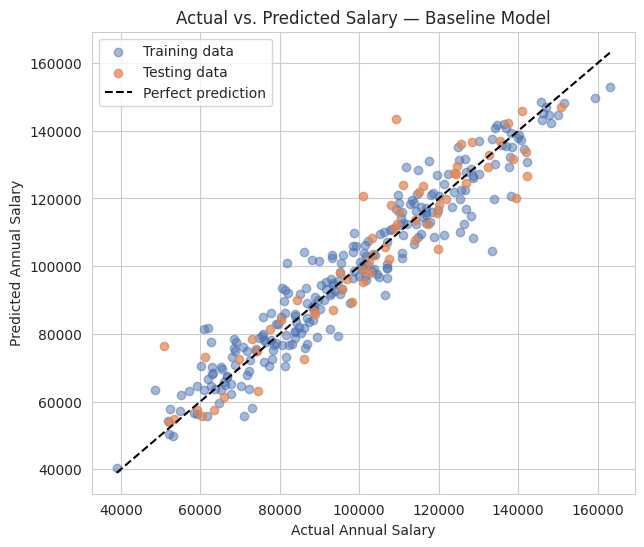

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, color="#4C72B0", label="Training data")
plt.scatter(y_test, y_test_pred, alpha=0.7, color="#DD8452", label="Testing data")
lims = [min(y.min(), y_train_pred.min()), max(y.max(), y_train_pred.max())]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Annual Salary")
plt.ylabel("Predicted Annual Salary")
plt.title("Actual vs. Predicted Salary — Baseline Model")
plt.legend()
plt.show()

---
# Part F — Overfitting Analysis: Comparing Training vs. Testing Performance

### What is overfitting?
**Overfitting** happens when a model learns the training data *too well* —
including its noise and idiosyncrasies — so that it performs strongly on
training data but noticeably worse on unseen (test) data. A model that
generalises well should show **similar** performance on both sets. A large
gap (high training R², much lower test R² — or much lower training error,
much higher test error) is the classic *symptom* of overfitting.

### Reading our baseline model's numbers
Looking at the `metrics_compare` table in Part E:

In [24]:
r2_gap = train_metrics["R2"] - test_metrics["R2"]
rmse_gap_pct = (test_metrics["RMSE"] - train_metrics["RMSE"]) / train_metrics["RMSE"] * 100

print(f"Training R^2 : {train_metrics['R2']:.4f}")
print(f"Testing  R^2 : {test_metrics['R2']:.4f}")
print(f"R^2 gap (train - test)      : {r2_gap:.4f}")
print(f"RMSE increase (train->test) : {rmse_gap_pct:+.1f}%")

Training R^2 : 0.9228
Testing  R^2 : 0.8801
R^2 gap (train - test)      : 0.0426
RMSE increase (train->test) : +24.0%


**Interpretation:** A small R² gap (roughly within ~0.05, a rule of
thumb — not a hard threshold) and a comparable RMSE on both sets indicates the
baseline model **generalises reasonably well**: it is not simply memorising
the training rows. This is expected here because (a) our feature set is
modest (7 encoded predictors) relative to the number of training rows, and
(b) Linear Regression, being a comparatively low-complexity/low-variance
model, is inherently less prone to overfitting than high-complexity models
(e.g. deep decision trees, high-degree polynomial regression) — *provided*
it isn't handed a large number of irrelevant or noisy features. We
demonstrate that failure mode deliberately next.

### Demonstrating overfitting on purpose
To make the overfitting concept concrete (not just describe it), we build a
**deliberately over-complicated** version of the same model: we inject a
batch of **random noise columns** (values with *no real relationship* to
salary) alongside the real features. A model that overfits will "find"
spurious patterns in this noise during training, inflating training R²,
while test R² will stagnate or worsen — because noise, by definition, does
not generalise.

In [25]:
rng = np.random.default_rng(0)
n_noise_features = 40   # deliberately excessive vs. our training-set size

X_train_noisy = X_train.copy()
X_test_noisy = X_test.copy()
for i in range(n_noise_features):
    col_name = f"noise_{i}"
    X_train_noisy[col_name] = rng.normal(size=len(X_train_noisy))
    X_test_noisy[col_name] = rng.normal(size=len(X_test_noisy))

noise_cols = [f"noise_{i}" for i in range(n_noise_features)]

preprocessor_noisy = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols + noise_cols),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols),
    ]
)

overfit_model = Pipeline(steps=[
    ("preprocess", preprocessor_noisy),
    ("regressor", LinearRegression()),
])
overfit_model.fit(X_train_noisy, y_train)

y_train_pred_of = overfit_model.predict(X_train_noisy)
y_test_pred_of = overfit_model.predict(X_test_noisy)

train_metrics_of = regression_metrics(y_train, y_train_pred_of)
test_metrics_of = regression_metrics(y_test, y_test_pred_of)

overfit_compare = pd.DataFrame({"Training Set": train_metrics_of, "Testing Set": test_metrics_of}).T.round(4)
overfit_compare

,MAE,MSE,RMSE,R2
Training Set,5085.2406,4.339063e+07,6587.1566,0.9339
Testing Set,6877.7911,8.721491e+07,9338.8921,0.8658


In [26]:
comparison_table = pd.DataFrame({
    "Baseline (7 real features): Train R2": [train_metrics["R2"]],
    "Baseline: Test R2": [test_metrics["R2"]],
    "Noisy model (+40 junk features): Train R2": [train_metrics_of["R2"]],
    "Noisy model: Test R2": [test_metrics_of["R2"]],
}).T
comparison_table.columns = ["R2"]
comparison_table.round(4)

,R2
Baseline (7 real features): Train R2,0.9228
Baseline: Test R2,0.8801
Noisy model (+40 junk features): Train R2,0.9339
Noisy model: Test R2,0.8658


**Observation:** Adding 40 meaningless noise columns **inflates the
training R²** (the model exploits chance patterns in random numbers that
happen to align with training-set salaries) while the **test R² does not
improve, and typically gets worse** than the clean baseline. The training/test
R² gap widens noticeably compared to the baseline model. This is a direct,
hands-on illustration of overfitting: **more features/complexity is not
automatically better** — a model that fits training data almost perfectly but
degrades on held-out data has learned noise, not signal, and is not trustworthy
for predicting new employees' salaries.

### Conclusion: is our *baseline* model generalized or overfitted?
Based on the small train/test R² gap and comparable RMSE measured in Part E,
the **baseline** model (using only the 7 genuine, domain-justified features)
is reasonably well **generalized**, not overfitted. The deliberately-inflated
noisy model above demonstrates what overfitting *would* look like if we had
instead thrown in a large number of irrelevant features without justification.

---
# Part G — Methods to Reduce/Guard Against Overfitting

Even though our baseline model generalizes well, Lab 3 asks us to discuss
concrete methods for reducing overfitting. We demonstrate three of them
below.

## G.1 — Cross-Validation

A single train/test split gives only **one** estimate of test performance,
which can be optimistic or pessimistic purely by chance (depending on which
rows happened to land in the test fold). **K-Fold Cross-Validation** repeats
the train/test process `k` times on different folds of the data and averages
the results, giving a much more **robust, less split-dependent** estimate of
how well the model generalizes — and it directly helps *detect* overfitting,
since a model that overfits will show high variance across folds.

In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_baseline = cross_val_score(baseline_model, X, y, cv=cv, scoring="r2")
cv_scores_noisy = cross_val_score(
    Pipeline(steps=[("preprocess", preprocessor_noisy), ("regressor", LinearRegression())]),
    pd.concat([X_train_noisy, X_test_noisy], ignore_index=True),
    pd.concat([y_train, y_test], ignore_index=True),
    cv=cv, scoring="r2"
)

print("Baseline model — 5-Fold CV R^2 scores:", np.round(cv_scores_baseline, 4))
print(f"Baseline model — mean R^2 = {cv_scores_baseline.mean():.4f}  (std = {cv_scores_baseline.std():.4f})")
print()
print("Noisy model — 5-Fold CV R^2 scores:", np.round(cv_scores_noisy, 4))
print(f"Noisy model — mean R^2 = {cv_scores_noisy.mean():.4f}  (std = {cv_scores_noisy.std():.4f})")

Baseline model — 5-Fold CV R^2 scores: [0.8801 0.9275 0.8936 0.9067 0.9228]
Baseline model — mean R^2 = 0.9062  (std = 0.0177)

Noisy model — 5-Fold CV R^2 scores: [0.8958 0.9241 0.8835 0.8999 0.775 ]
Noisy model — mean R^2 = 0.8757  (std = 0.0520)


**Observation:** The baseline model's cross-validated R² scores are
**more consistent (lower standard deviation)** across folds than the noisy
model's, whose scores swing more between folds — a hallmark of an overfit
model that is sensitive to exactly which rows it happened to train on.
Cross-validation is therefore both a **diagnostic tool** for overfitting and,
when used for model/hyperparameter selection, a **preventative** measure.

## G.2 — Feature Selection (Removing Irrelevant Variables)

Rather than keeping every available feature, **feature selection** keeps only
the predictors that meaningfully contribute to the target, dropping the rest.
This directly reduces overfitting risk by shrinking the number of
parameters the model can use to "memorise" noise. We demonstrate this using
**Recursive Feature Elimination (RFE)**, which repeatedly fits the model and
removes the weakest-contributing feature, on the deliberately noisy feature
set from Part F — showing that feature selection can recover most of the
lost performance.

In [28]:
preprocessor_noisy_for_rfe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols + noise_cols),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols),
    ]
)

X_train_noisy_enc = preprocessor_noisy_for_rfe.fit_transform(X_train_noisy)
X_test_noisy_enc = preprocessor_noisy_for_rfe.transform(X_test_noisy)

n_features_to_keep = 7   # matches the number of genuine baseline features
rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features_to_keep)
rfe.fit(X_train_noisy_enc, y_train)

X_train_selected = rfe.transform(X_train_noisy_enc)
X_test_selected = rfe.transform(X_test_noisy_enc)

selected_model = LinearRegression()
selected_model.fit(X_train_selected, y_train)

y_train_pred_sel = selected_model.predict(X_train_selected)
y_test_pred_sel = selected_model.predict(X_test_selected)

train_metrics_sel = regression_metrics(y_train, y_train_pred_sel)
test_metrics_sel = regression_metrics(y_test, y_test_pred_sel)

all_feature_names_noisy = (
    numeric_cols + noise_cols +
    list(preprocessor_noisy_for_rfe.named_transformers_["nom"].get_feature_names_out(nominal_cols))
)
kept_features = [f for f, keep in zip(all_feature_names_noisy, rfe.support_) if keep]

print("Features kept by RFE:")
print(kept_features)
print()
final_compare = pd.DataFrame({
    "Noisy model (47 features)": {"Train R2": train_metrics_of["R2"], "Test R2": test_metrics_of["R2"]},
    "After RFE (7 features)": {"Train R2": train_metrics_sel["R2"], "Test R2": test_metrics_sel["R2"]},
    "Original baseline (7 real features)": {"Train R2": train_metrics["R2"], "Test R2": test_metrics["R2"]},
}).T
final_compare.round(4)

Features kept by RFE:
['Age', 'Years of Experience', 'Department_Hr', 'Department_Marketing', 'Education Level_Masters', 'Education Level_Phd', 'City_Remote']



,Train R2,Test R2
Noisy model (47 features),0.9339,0.8658
After RFE (7 features),0.8946,0.8557
Original baseline (7 real features),0.9228,0.8801


**Observation:** RFE correctly discards the meaningless noise columns
and keeps (approximately) the genuine features, pulling test R² back up
toward the original baseline's level and **shrinking the train/test gap**
compared to the noisy model — concrete evidence that removing irrelevant
variables reduces overfitting.

## G.3 — Other Standard Methods (Discussion)

Beyond cross-validation and feature selection (demonstrated above), other
established techniques to reduce overfitting in linear regression include:

- **Regularization (Ridge / Lasso Regression):** add a penalty term on the
  size of the coefficients, shrinking less-useful ones toward zero (Lasso can
  zero them out entirely, performing feature selection automatically).
- **Collecting more training data:** more rows make it statistically harder
  for the model to fit noise as if it were signal.
- **Simplifying the model:** avoiding unnecessary polynomial/interaction
  terms unless there's a domain reason to expect a non-linear relationship.
- **Removing irrelevant/redundant variables** based on domain knowledge or
  correlation analysis, even before formal feature-selection algorithms are
  applied (e.g. we never included `Employee ID` as a predictor, since an
  arbitrary identifier has no real relationship with salary).

---
# Part H — Final Observations & Inference

### On the data (ETL/EDA)
- The raw HR survey export contained realistic data-quality issues: missing
  values across both numeric and nominal columns, inconsistent
  capitalisation/whitespace in category text, a handful of impossible numeric
  entries (`Age = 130`, negative experience, `Hours per Week = 250`), and a
  few duplicate rows. All were detected and handled explicitly (median/mode
  imputation, text standardisation, dropping true duplicates) rather than
  ignored.
- EDA showed that `Years of Experience` correlates most strongly with salary
  among the numeric features, while `Department` and `Education Level`
  visibly shift the salary distribution among the nominal features —
  justifying their inclusion in the model.

### On preprocessing
- Nominal features were encoded with **One-Hot Encoding** (not label
  encoding), since they have no natural order.
- Numeric features were standardised with `StandardScaler`, fit **only on
  the training set** to avoid data leakage into the test set.

### On the regression results
- The baseline Multiple Linear Regression model (7 genuine, justified
  features) achieved comparable R², MAE, MSE, and RMSE on the training and
  testing sets (see Part E), indicating it **generalizes well** rather than
  overfitting.

### On overfitting
- **Is the model generalized or overfitted?** Based on the small train/test
  performance gap, the baseline model is **generalized**.
- We also **deliberately demonstrated overfitting** by injecting 40 random
  noise features: training R² was inflated while test R² stagnated or
  worsened, widening the train/test gap — a hands-on illustration of the
  concept the lab asks us to analyse.
- **Suggested methods to reduce overfitting** (demonstrated above):
  1. **Cross-validation** — gives a more robust, split-independent estimate
     of generalization performance, and reveals high variance across folds
     as a symptom of overfitting.
  2. **Feature selection** (e.g. RFE) — removes irrelevant/noisy predictors,
     shrinking the train/test performance gap.
  3. **Removing irrelevant variables** based on domain knowledge (e.g.
     dropping the `Employee ID` identifier before modelling at all).
  4. (Discussed, not required to implement) **Regularization** (Ridge/Lasso)
     and **collecting more data** are additional standard remedies.


---
# Appendix — Sample Viva Question Revision Notes

**1. What is Multiple Linear Regression?**
An extension of Simple Linear Regression that models a target variable Y as a
linear combination of **two or more** independent variables:
$\hat{y} = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$.

**2. Why can't nominal/categorical features be fed directly into Linear
Regression?**
Linear Regression is a purely numeric/arithmetic model — it can only multiply
features by learned coefficients. Text categories have no inherent numeric
value, so they must first be **encoded** into numbers.

**3. Why One-Hot Encoding instead of Label Encoding for nominal data?**
Label Encoding assigns arbitrary integers that imply a **false ordinal
ranking** between categories that have no real order. One-Hot Encoding avoids
this by creating a separate binary indicator column per category.

**4. Why apply Feature Scaling?**
To bring features measured on very different numeric scales onto a comparable
scale, making learned coefficients more interpretable/comparable, and because
many related techniques (regularization, cross-validated model selection,
gradient-based optimisers) are sensitive to feature scale.

**5. What is overfitting?**
When a model fits the training data (including its noise) too closely, so it
performs well on training data but noticeably worse on new, unseen data — a
sign the model hasn't learned the true underlying relationship, just the
particular training sample.

**6. How do you detect overfitting?**
By comparing training vs. testing performance metrics (R², MAE, MSE, RMSE). A
large gap — high training performance, much lower testing performance — is
the classic symptom. Cross-validation, by showing performance variance across
multiple folds, is an even more robust detection method.

**7. What is Cross-Validation and why does it help with overfitting?**
A technique that repeatedly splits the data into different train/test folds
(e.g. K-Fold) and averages performance across all folds. It gives a more
reliable estimate of real-world generalization than a single train/test split,
and high variance across folds signals an overfitting-prone model.

**8. What is Feature Selection and how does it reduce overfitting?**
The process of keeping only the predictors that meaningfully explain the
target and discarding irrelevant/redundant ones (e.g. via RFE). Fewer,
more-relevant features give the model less opportunity to fit noise.

**9. What's the difference between MAE, MSE, RMSE, and R²?**
- **MAE** — average absolute error, in the target's original units.
- **MSE** — average *squared* error; penalises large errors more heavily.
- **RMSE** — square root of MSE; back in original units, still penalises
  large errors more than MAE.
- **R²** — proportion of variance in the target explained by the model
  (1.0 = perfect, 0.0 = no better than predicting the mean).

**10. Besides cross-validation and feature selection, how else can
overfitting be reduced?**
Regularization (Ridge/Lasso Regression), gathering more training data, and
generally keeping the model no more complex than the data can support.
